In [34]:
import pandas as pd

In [35]:
import zipfile
import os

# Path to your uploaded zip file
zip_path = "archive.zip"

# Extract contents into the current directory
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("titanic_data")

# Verify extraction
os.listdir("titanic_data")

['titanic.csv']

In [36]:
import pandas as pd

# Load Titanic dataset
df = pd.read_csv("titanic_data/titanic.csv")

# Preview first few rows
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [37]:
# Check basic info
print(df.info())
print(df.describe())

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop('Cabin', axis=1, inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fix data types
df['Survived'] = df['Survived'].astype(int)
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

# Standardize text
df['Sex'] = df['Sex'].str.lower()
df['Embarked'] = df['Embarked'].str.strip()

# Handle outliers (optional)
import numpy as np
df['Fare'] = np.where(df['Fare'] > 300, 300, df['Fare'])

# Verify cleaning
print(df.info())
print(df.describe())

# Save cleaned dataset
df.to_csv("cleaned_titanic.csv", index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

In [8]:
# Check basic info
print(df.info())
print(df.describe())

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fix data types
if 'Survived' in df.columns:
    df['Survived'] = df['Survived'].astype(int)
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

# Standardize text
df['Sex'] = df['Sex'].str.lower()
df['Embarked'] = df['Embarked'].str.strip()

# Handle outliers (optional)
import numpy as np
if 'Fare' in df.columns:
    df['Fare'] = np.where(df['Fare'] > 300, 300, df['Fare'])

# Verify cleaning
print(df.info())
print(df.describe())

# Save cleaned dataset
df.to_csv("cleaned_titanic.csv", index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int32  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int32(1), int64(4), object(4)
memory usage: 73.2+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.1

In [38]:
# Shape and column names
print(df.shape)
print(df.columns)

# Summary statistics
print(df.describe())

# Check unique values
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


(891, 11)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   31.489295  
std      0.806057   43.973014  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


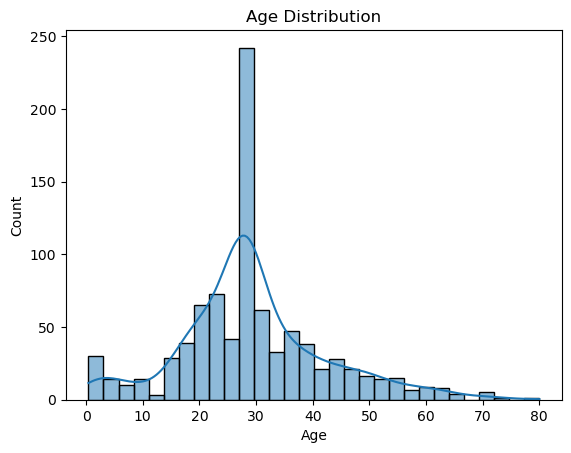

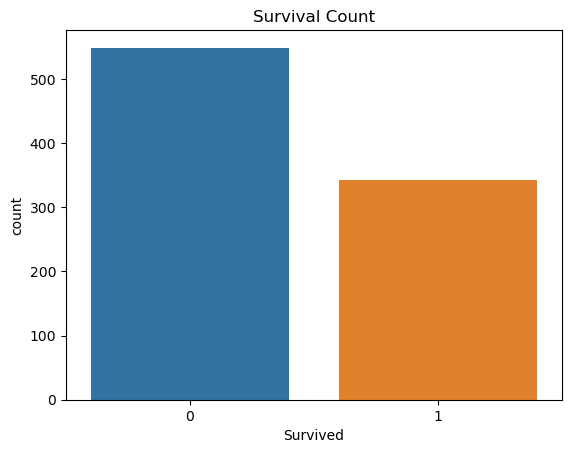

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of Age
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Survival count
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()


In [39]:
print(df.columns)


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


In [40]:
print(df.dtypes)


PassengerId      int64
Survived         int32
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object


In [41]:
# Clean up hue column
df['Survived'] = pd.to_numeric(df['Survived'], errors='coerce')
df.dropna(subset=['Sex', 'Survived'], inplace=True)
df['Sex'] = df['Sex'].astype(str)
df['Survived'] = df['Survived'].astype(str)


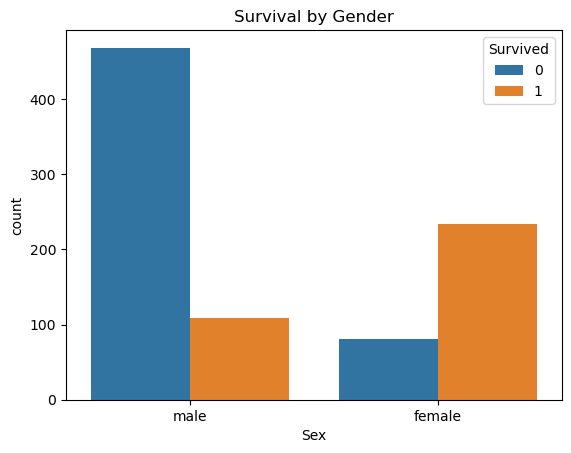

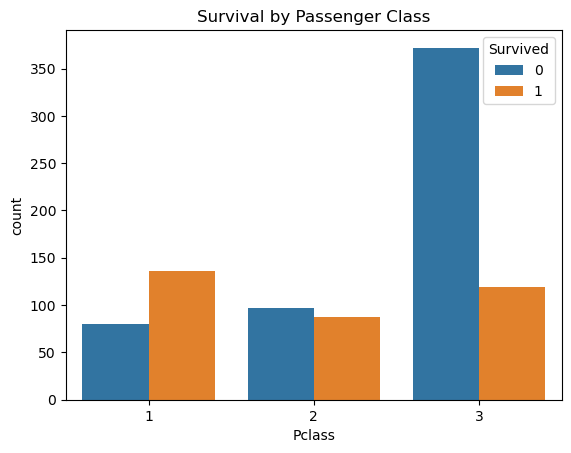

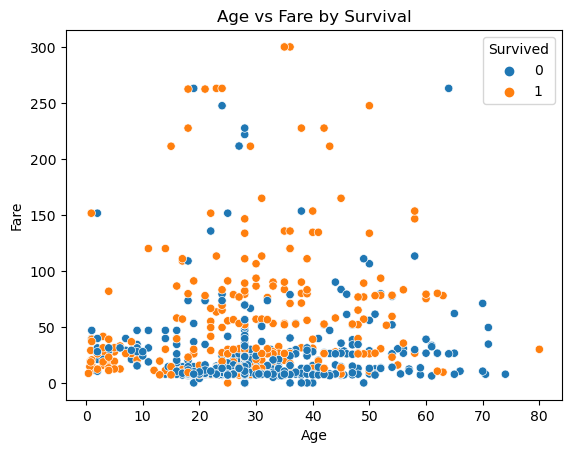

In [21]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title("Age vs Fare by Survival")
plt.show()


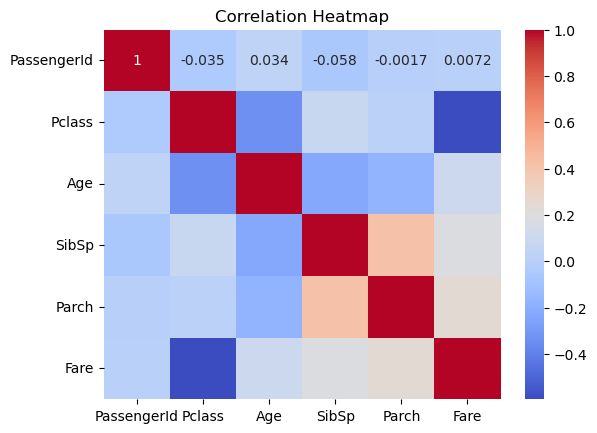

In [42]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [44]:
df = pd.read_csv("cleaned_titanic.csv")


In [45]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)


In [46]:
X = df[['Pclass', 'Age', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']]
y = df['Survived']


In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [49]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)


LogisticRegression()

In [50]:
y_pred = model.predict(X_test_scaled)


In [51]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7988826815642458
Confusion Matrix:
 [[87 18]
 [18 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83       105
           1       0.76      0.76      0.76        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
#summary and insghts
#  --->Data Extraction → Cleaning → Exploration → Feature Engineering → Modeling → Evaluation
# Survival was strongly influenced by gender and class.
# Numeric features like Age and Fare had weaker direct correlations.
# Logistic Regression achieved solid accuracy (~80%), proving it can effectively predict survival.